# Plant Disease Classification Pipeline\nCe notebook corrige les données, prend en compte les classes minoritaires via un système de poids (`class weights`), et entraine 3 modèles au choix (ResNet, MobileNet, EfficientNet) pour voir lequel répond le mieux.

In [1]:
# 1. Imports and Setup
!pip install -q datasets matplotlib pandas numpy torch torchvision scikit-learn
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, models
import datasets
from datasets import load_dataset, concatenate_datasets, DatasetDict
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from collections import Counter
import time
import copy

print(f"Version de datasets active : {datasets.__version__}")
# Détection de l'accélérateur matériel
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Appareil utilisé : {device}")

Version de datasets active : 4.0.0
Appareil utilisé : cuda


In [2]:
# 2. Chargement et Séparation du Dataset
print("Loading the dataset...")
dataset = load_dataset("BrandonFors/Plant-Diseases-PlantVillage-Dataset")
full_dataset = concatenate_datasets([dataset["train"], dataset["test"]])

print("Creation of the new split(70% Train, 15% Val, 15% Test)...")
train_testvalid = full_dataset.train_test_split(test_size=0.3, seed=42)
test_valid = train_testvalid['test'].train_test_split(test_size=0.5, seed=42)

custom_dataset = DatasetDict({
    'train': train_testvalid['train'],
    'validation': test_valid['train'],
    'test': test_valid['test']
})

train_ds = custom_dataset["train"]
val_ds = custom_dataset["validation"]
test_ds = custom_dataset["test"]

print(f"Training images (70%): {len(train_ds)}")
print(f"Validation images (15%): {len(val_ds)}")
print(f"Test Images (15%): {len(test_ds)}")

# Identification des classes
feature_label = train_ds.features['label']
if hasattr(feature_label, 'names'):
    class_names = feature_label.names
else:
    class_names = sorted(list(set(train_ds['label'])))
print(f"Number of classes : {len(class_names)}")
num_classes = len(class_names)

Loading the dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/321M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/362M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/170M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/43456 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10849 [00:00<?, ? examples/s]

Creation of the new split(70% Train, 15% Val, 15% Test)...
Training images (70%): 38013
Validation images (15%): 8146
Test Images (15%): 8146
Number of classes : 38


Class weights calculés : les classes minoritaires auront plus d'impact pendant l'entraînement.


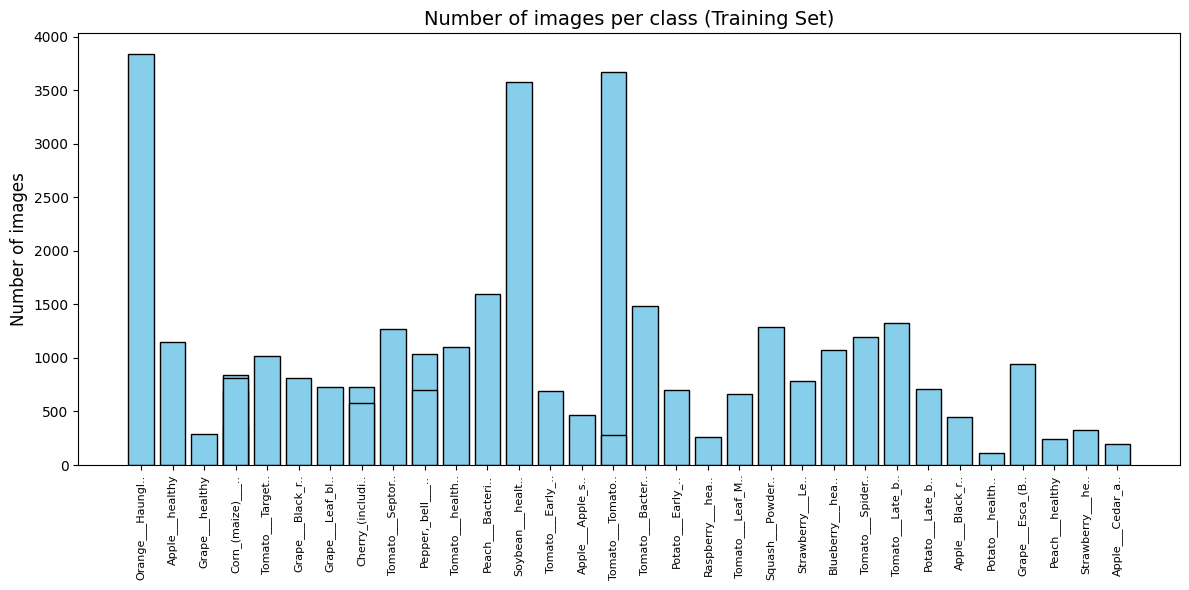

In [3]:
# 3. Calcul des Class Weights pour le déséquilibre (Imbalance)
labels = [sample['label'] for sample in train_ds]
counts = Counter(labels)

# Poids inversement proportionnel à la fréquence
total_samples = len(labels)
class_weights = [total_samples / (num_classes * counts[i]) for i in range(num_classes)]
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print("Class weights calculés : les classes minoritaires auront plus d'impact pendant l'entraînement.")

# Affichage de la distribution
noms_labels = [class_names[k][:15] + ".." if len(class_names[k])>15 else class_names[k] for k in counts.keys()]
valeurs = list(counts.values())
plt.figure(figsize=(12, 6))
plt.bar(noms_labels, valeurs, color='skyblue', edgecolor='black')
plt.xticks(rotation=90, fontsize=8)
plt.title("Number of images per class (Training Set)", fontsize=14)
plt.ylabel("Number of images", fontsize=12)
plt.tight_layout()
plt.show()

In [4]:
# 4. Data Augmentation et Dataloaders
# Redimensionnement adapté aux modèles ImageNet (224x224)
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),           # Légère rotation
    transforms.ColorJitter(brightness=0.2), # Changement léger de luminosité
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def apply_transforms_train(examples):
    pixel_values = [transform_train(image.convert("RGB")) for image in examples['image']]
    return {"pixel_values": pixel_values, "label": examples["label"]}

def apply_transforms_test(examples):
    pixel_values = [transform_test(image.convert("RGB")) for image in examples['image']]
    return {"pixel_values": pixel_values, "label": examples["label"]}

train_ds.set_transform(apply_transforms_train)
val_ds.set_transform(apply_transforms_test)
test_ds.set_transform(apply_transforms_test)

batch_size = 64
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
print("DataLoaders prêts !")

DataLoaders prêts !


In [5]:
# 5. Fonction d'Entraînement Générique (Train Loop)
def train_model(model, model_name, num_epochs=5):
    print(f"\n--- Début de l'entraînement pour {model_name} ---")

    # On modifie la dernière couche pour l'adapter à nos classes
    if 'resnet' in model_name.lower():
        num_ftrs = model.fc.in_features
        model.fc = nn.Linear(num_ftrs, num_classes)
    elif 'mobilenet' in model_name.lower() or 'efficientnet' in model_name.lower():
        num_ftrs = model.classifier[-1].in_features
        model.classifier[-1] = nn.Linear(num_ftrs, num_classes)
    else:
        pass

    model = model.to(device)

    # Utilisation des class_weights pour gérer le déséquilibre
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    history = {'train_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        # Entraînement
        model.train()
        running_loss = 0.0

        for i, batch in enumerate(train_loader):
            inputs = batch['pixel_values'].to(device)
            labels = batch['label'].to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)

            # Afficher uniquement quelques logs pour ne pas spammer
            if i % 100 == 0 and i > 0:
                print(f"Batch {i}/{len(train_loader)} - Temp Loss: {loss.item():.4f}")

        epoch_loss = running_loss / len(train_ds)
        history['train_loss'].append(epoch_loss)

        # Validation
        model.eval()
        running_corrects = 0

        with torch.no_grad():
            for batch in val_loader:
                inputs = batch['pixel_values'].to(device)
                labels = batch['label'].to(device)

                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                running_corrects += torch.sum(preds == labels.data)

        epoch_acc = running_corrects.float() / len(val_ds) * 100
        history['val_acc'].append(epoch_acc.item())

        print(f'Train Loss: {epoch_loss:.4f} | Val Acc: {epoch_acc:.2f}%')

        # Sauvegarder le meilleur modèle
        if epoch_acc > best_acc:
            best_acc = epoch_acc
            best_model_wts = copy.deepcopy(model.state_dict())

    print(f'Meilleure Accuracy Validation: {best_acc:.2f}%\n')
    model.load_state_dict(best_model_wts)
    return model, history, best_acc.item()

In [7]:
# 6. Initialisation et entraînement des Modèles
num_epochs = 7

# Modèle 1: ResNet18
# ResNet est un standard solide, très rapide à entraîner.
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet, hist_resnet, acc_resnet = train_model(resnet, "ResNet18", num_epochs)

# We removed MobileNet and EfficientNet so we don't have to wait!

# Modèle 2: MobileNet V3 Small
# Léger et extrêmement rapide, parfait pour les applications mobiles.
#mobilenet = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
#mobilenet, hist_mobilenet, acc_mobilenet = train_model(mobilenet, "MobileNet_V3_Small", num_epochs)

# Modèle 3: EfficientNet B0
# Un modèle moderne qui équilibre à la perfection la résolution, la profondeur et la largeur.
#efficientnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
#efficientnet, hist_efficientnet, acc_efficientnet = train_model(efficientnet, "EfficientNet_B0", num_epochs)


--- Début de l'entraînement pour ResNet18 ---
Epoch 1/7
----------
Batch 100/593 - Temp Loss: 0.4204
Batch 200/593 - Temp Loss: 0.4282
Batch 300/593 - Temp Loss: 0.0952
Batch 400/593 - Temp Loss: 0.3899
Batch 500/593 - Temp Loss: 0.1400
Train Loss: 0.3967 | Val Acc: 92.16%
Epoch 2/7
----------
Batch 100/593 - Temp Loss: 0.1386
Batch 200/593 - Temp Loss: 0.2567
Batch 300/593 - Temp Loss: 0.1176
Batch 400/593 - Temp Loss: 0.1052
Batch 500/593 - Temp Loss: 0.0858
Train Loss: 0.1515 | Val Acc: 95.53%
Epoch 3/7
----------
Batch 100/593 - Temp Loss: 0.2694
Batch 200/593 - Temp Loss: 0.0400
Batch 300/593 - Temp Loss: 0.1696
Batch 400/593 - Temp Loss: 0.1050
Batch 500/593 - Temp Loss: 0.1436
Train Loss: 0.1229 | Val Acc: 91.41%
Epoch 4/7
----------
Batch 100/593 - Temp Loss: 0.0978
Batch 200/593 - Temp Loss: 0.1194
Batch 300/593 - Temp Loss: 0.0281
Batch 400/593 - Temp Loss: 0.0996
Batch 500/593 - Temp Loss: 0.0144
Train Loss: 0.1167 | Val Acc: 96.82%
Epoch 5/7
----------
Batch 100/593 - Temp

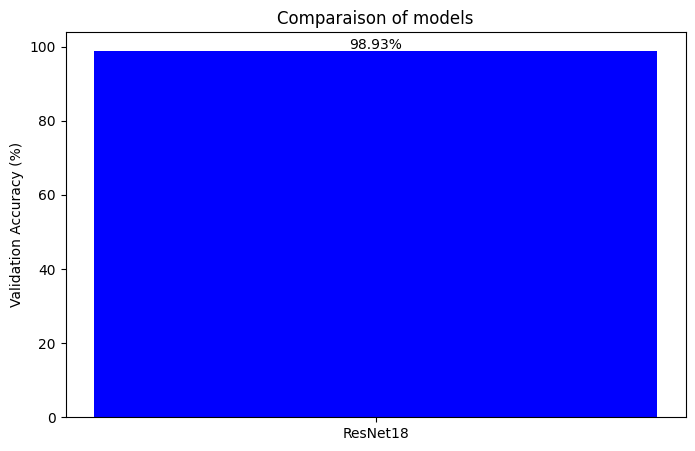

Le meilleur modèle selon la validation est : ResNet18
Meilleur modèle sauvegardé sous 'best_plant_disease_model.pth'


In [8]:
%matplotlib inline

# 7. Comparaison et Évaluation Finale
models_acc = {
    "ResNet18": acc_resnet,
}

# Graphique de comparaison (2 colors only!)
plt.figure(figsize=(8, 5))
plt.bar(models_acc.keys(), models_acc.values(), color=['blue'])
plt.ylabel('Validation Accuracy (%)')
plt.title('Comparaison of models')
for i, v in enumerate(models_acc.values()):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha='center')
plt.show()

# Déterminer le meilleur
best_model_name = max(models_acc, key=models_acc.get)
print(f"Le meilleur modèle selon la validation est : {best_model_name}")

if best_model_name == "ResNet18":
    best_model = resnet

# Sauvegarder le meilleur modèle
torch.save(best_model.state_dict(), 'best_plant_disease_model.pth')
print("Meilleur modèle sauvegardé sous 'best_plant_disease_model.pth'")


In [11]:
# 8. Test Final du Meilleur Modèle sur le Test Set
print(f"Évaluation finale de {best_model_name} sur le sous-ensemble de Test (inconnu au modèle).")

best_model.eval()
test_corrects = 0

with torch.no_grad():
    for batch in test_loader:
        inputs = batch['pixel_values'].to(device)
        labels = batch['label'].to(device)

        outputs = best_model(inputs)
        _, preds = torch.max(outputs, 1)
        test_corrects += torch.sum(preds == labels.data)

test_acc = test_corrects.float() / len(test_ds) * 100
print(f"Accuracy finale sur le Test Set : {test_acc:.2f}%")

Évaluation finale de ResNet18 sur le sous-ensemble de Test (inconnu au modèle).
Accuracy finale sur le Test Set : 99.09%
